## Hello World Graph

Below is the workflow of creating a very basic graph in Langgraph by defining state structure using TypedDict and using the State to define the graph which is later compiled and invoked

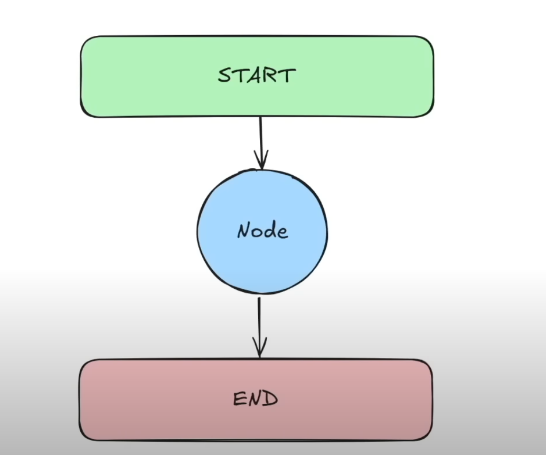

In [7]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [8]:
class AgentState(TypedDict):  ### STATE SCHEMA
    message: str

def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] = 'Hey ' + state['message'] + ', how is your day going?'

    return state


In [9]:
graph = StateGraph(AgentState)

graph.add_node('Greeting', greeting_node)
graph.set_entry_point('Greeting')
graph.set_finish_point('Greeting')

app = graph.compile()

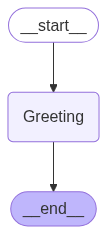

In [10]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
result = app.invoke({'message':'Cena'})
result['message']

'Hey Cena, how is your day going?'